In [3]:
import os
if not os.path.isdir('/content/ssm'):
    !git clone -q https://github.com/JohnEkD/ssm-workshop.git /content/ssm
%cd /content/ssm
import sys; sys.path.insert(0, '/content/ssm/shared/lib')

/content/ssm


<p align="center">
<img src="/content/ssm/shared/diagrams/afrismat_logo.png" width="420"><br>
<em></em>
</p>

https://colab.research.google.com/github/JohnEkD/ssm-workshop/blob/main/onramp_0_prework/O0_prework_STUDENT.ipynb

---
---
# **On-ramp 0 - Where is the hand, and how far is it from the person?**

### If you have never written Python, start here. This is written for you.

You do not need any prior programming. Everything is introduced at the moment we
need it, and every step is checked as you go.

### One question runs the whole hour

A robot arm shares a bench with a person. Everything the workshop does for three
days rests on a single number: **how far is the nearest part of the robot from
the nearest part of the person?** Get that number, and the safety mathematics
has something to work with. Get it wrong, and nothing downstream can save you.

So that is what you will build. By the end of this notebook you will have
written, from nothing:

- where any point on the arm is, given its joint angles
- how far that is from a person standing nearby
- which part of the arm is closest - because **it is not always the hand**
- and a first optimisation, which is the tool that keeps the two apart

### Learning outcomes

1. **Run** a Colab notebook and explain why cell order matters.
2. **Write** a Python function with arguments and a return value.
3. **Use** a NumPy array as a point in space, and take a distance.
4. **Loop** over a list of points and pick out a minimum.
5. **Tell** a symbolic expression from a number, and say why that distinction
   exists.
6. **Solve** a constrained optimisation and read what the solver did.

**About 60 minutes.** Take longer if you need to - nobody is watching.

> ### How the questions work
> Each one has blanks marked `...`. Fill them in, run the cell, then run the
> check below it. There is a **Hint** above every question and the **answer**
> below the check - open the answer once you have tried, not before. That is not
> a rule for its own sake: the attempt is what makes the answer stick.

---
---
## 0 - How a notebook works

A notebook is a column of **cells**. A code cell runs Python; a text cell (like
this one) is just words.

To run a cell: click it and press **Shift + Enter**.

Run the next one.

In [4]:
print("The cell ran.")
2 + 2

The cell ran.


4

Two things happened. `print(...)` showed text, and the **last line's value**
was displayed on its own. That second behaviour is why you often see a bare
variable name at the end of a cell.

---
### The one trap that catches everybody

A notebook remembers what you ran, **in the order you ran it** - not in the
order the cells appear on screen. Run the next two cells top to bottom, then go
back and run the *first* of them again, and watch the number.

In [5]:
counter = 0
counter = counter + 1
counter

1

If you ran that cell three times you saw `1` three times, because the first
line resets it. But delete the first line and re-run, and the number climbs.

> **A notebook's state is the history of what you ran, not what is on the page.**
> Almost every "but it worked a minute ago" comes from this. When something is
> inexplicable: **Runtime → Restart session**, then run from the top.


---
#### Try it A — driving Colab
*Not graded.*

| you want | how |
|---|---|
| run a cell | `Shift + Enter` |
| run without moving on | `Ctrl + Enter` |
| **new code cell below** | hover between cells &rarr; **+ Code**, or `Ctrl + M` then `B` |
| **new text cell below** | hover between cells &rarr; **+ Text**, or `Ctrl + M` then `M` |
| **delete a cell** | click it, then `Ctrl + M` then `D` |
| **edit a text cell** | **double-click** it. `Shift + Enter` to render it again |
| move a cell up or down | the arrow buttons in the cell's toolbar (top-right on hover) |
| undo a deleted cell | `Ctrl + M` then `Z` |
| everything is broken | **Runtime &rarr; Restart session**, then run from the top |

A cell's toolbar appears at its top-right when you hover over it.

On a Mac, `Ctrl + M` is still `Ctrl`, not `Cmd`.

In [6]:
# Try it: add a new code cell BELOW this one, make it print your name, run it,
# then delete it again. Nothing in this notebook depends on it.
print("this cell is safe to experiment around")

this cell is safe to experiment around


Double-click this line, change the word *banana* to something else, then press
`Shift + Enter` to render it again. Nothing depends on what it says.

---
Now the setup cell. `import` brings in code somebody else wrote.

In [13]:
!pip -q install casadi==3.7.2 2>/dev/null
import sys, os
sys.path[:0] = [p for p in ('lib', '../shared/lib') if os.path.isdir(p)]
import numpy as np                  # arrays and maths
import matplotlib.pyplot as plt     # pictures
import casadi as ca                 # the optimiser, from section 6
import ssm_grader as grader         # the checks
print("ready")

ready


---
---
## **1 - Names and numbers**

A **variable** is a name for a value. `=` means *"let this name refer to this"* -
it is not the `=` of algebra.

```python
length = 0.5          # metres
```

Our arm has two links: an upper arm **0.5 m** long, and a forearm **0.4 m** long.

### Question 1
Give them names.

<details>
<summary><b>Hint &#9656;</b></summary>

Just two lines: `L1 = 0.5` and `L2 = 0.4`. Decimal points, no quotes - `"0.5"` with quotes would be *text*, not a number, and you cannot do arithmetic with text.

</details>

In [15]:
L1 = 0.5
L2 = 0.4
print(f"link 1 is {L1} m and link 2 is {L2} m")

link 1 is 0.5 m and link 2 is 0.4 m


In [16]:
grader.q0_1(L1, L2)

  PASS  1.1  the two link lengths


True

<details>
<summary><b>Show the answer &#9656;</b> <i>(try it first - that is where the learning is)</i></summary>

```python
L1 = 0.5
L2 = 0.4
print(f"link 1 is {L1} m and link 2 is {L2} m")
```

The `f` before the quotes makes an **f-string**: anything inside `{...}` is replaced by its value. You will use this constantly to print results.

</details>

---
#### Try it B — arithmetic
*Not graded. Run it, change a number, run it again.*

| operator | does | example | gives |
|---|---|---|---|
| `+` | add | `2 + 3` | `5` |
| `-` | subtract | `5 - 2` | `3` |
| `*` | multiply | `4 * 2.5` | `10.0` |
| `/` | divide | `5 / 2` | `2.5` — always a decimal |
| `**` | **power** | `3 ** 2` | `9` |
| `np.sqrt()` | **square root** | `np.sqrt(9)` | `3.0` |
| `()` | do this first | `(2 + 3) * 4` | `20` |

Watch `**` and `np.sqrt()`. They appear together in the braking distance
formula we will see later — how far a robot travels while stopping.

**Order of operations is the usual one** — powers, then `*` and `/`, then `+`
and `-`. When in doubt, add brackets; they cost nothing and never confuse the
next reader.

In [10]:
import numpy as np
print(2 + 3 * 4)          # 14, not 20 -- multiplication happens first
print((2 + 3) * 4)        # 20 -- brackets override
print(3 ** 2)             # 9
print(np.sqrt(9.0))       # 3.0
print(5 / 2)              # 2.5 -- division always gives a decimal

14
20
9
3.0
2.5


---
#### Try it B (continued) — put the arithmetic to work
*Still not graded.*

A vehicle is travelling at $v_{max}$ and can slow down at a rate $a_{max}$.
Two questions, and both are one line of arithmetic:

**How long does it take to stop?**

$$T_{stop} = \frac{v_{max}}{a_{max}}$$

**How far does it travel while stopping?**

$$d_{brake} = \frac{v_{max}^{\,2}}{2\,a_{max}}$$

Fill in the four blanks below for a vehicle at $v_{max} = 3.0$ m/s that can
brake at $a_{max} = 2.0$ m/s². Every operator you need is in the table above.

These two numbers come back later, and the second one turns up again inside the
safety standard itself.

<details>
<summary><b>Hint</b></summary>

The second one needs brackets around the whole denominator: `(2 * a_max)`.
Without them Python divides by 2 and then *multiplies* by `a_max` — wrong by a
factor of `a_max` squared.

</details>

In [17]:
v_max = 3.0
a_max = 2.0

stopping_time    = v_max / a_max
braking_distance = (v_max**2)/(2*a_max)

print(f"stopping time    {stopping_time:.2f} s")
print(f"braking distance {braking_distance:.2f} m")

stopping time    1.50 s
braking distance 2.25 m


---
#### Try it C — comparisons, and what they give back
*Not graded, and the most useful two minutes in this notebook.*

A comparison does not *do* anything. It **produces a value**: `True` or `False`.

| operator | asks | example | gives |
|---|---|---|---|
| `<` | less than | `3 < 5` | `True` |
| `>` | greater than | `3 > 5` | `False` |
| `<=` | less than **or equal** | `5 <= 5` | `True` |
| `>=` | greater than or equal | `4 >= 5` | `False` |
| `==` | **equal** — two equals signs | `3 == 3` | `True` |
| `!=` | not equal | `3 != 5` | `True` |

**One equals sign assigns. Two equals signs ask.**
`x = 5` sets x to 5. `x == 5` asks whether it already is.

Because `True` and `False` are values, you can print them, store them in a
variable, and count them — `True` counts as 1 and `False` as 0.

In [18]:
print(3 < 5)            # True
print(3 == 5)           # False  -- two equals signs
print(3 != 5)           # True

d = 0.42
print(d <= 0.5)         # True

answer = d <= 0.5       # a comparison stored in a variable
print(answer)           # True
print(int(answer))      # 1  -- True counts as one

True
False
True
True
True
1


Hold on to this. In section 8 you will meet a rule the solver must respect,
written `x >= 5`. On its own line it produces `True` or `False`, the notebook
throws that away, and **nothing happens** — silently. It becomes a rule only
when you hand it to the solver.

---
#### **Try it D — an array is a list of numbers**
*Not graded.*

A single number is a number. Two numbers that belong together — like the x and
y of a point — go in an **array**:

```python
p = np.array([0.5, 0.3])
```

Square brackets, comma-separated. Then:

| you write | you get |
|---|---|
| `p[0]` | the **first** entry — counting starts at zero |
| `p[1]` | the second |
| `p[-1]` | the last, counting from the end |

Arrays also do arithmetic **entry by entry**, which is why they are worth
having. Adding two points adds their x's together and their y's together, in
one line, with no loop.

In [19]:
p = np.array([0.5, 0.3])
q = np.array([0.2, 0.1])

print(p)            # [0.5 0.3]
print(p[0])         # 0.5  -- the first entry
print(p[1])         # 0.3
print(p + q)        # [0.7 0.4]  -- entry by entry
print(p * 2)        # [1.  0.6]  -- every entry doubled

[0.5 0.3]
0.5
0.3
[0.7 0.4]
[1.  0.6]


---
## **2 - Your first function, and a little trigonometry**
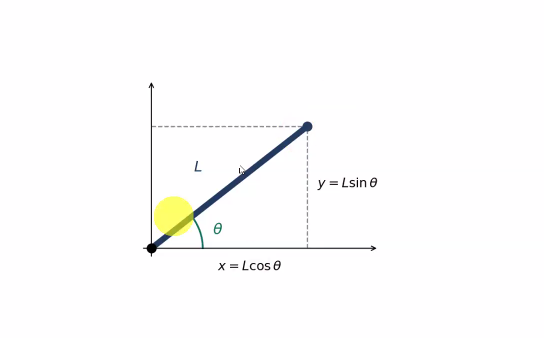
<p align="center">
<img src="/content/ssm/shared/diagrams/link_geometry.png" width="420"><br>
<em>One link at angle θ. Its far end sits at x = L cos θ, y = L sin θ.</em>
</p>


Picture one link, pinned at the origin, pointing at an angle $\theta$ from the
$x$-axis. Where does its far end sit?

$$x = \ell\cos\theta, \qquad y = \ell\sin\theta$$

That is the whole of the trigonometry in this notebook. If $\theta = 0$ the link
points right and ends at $(\ell, 0)$; if $\theta = 90°$ it points up and ends at
$(0, \ell)$.

A **function** packages that calculation so you can reuse it:

```python
def name(argument1, argument2):     # 'def' starts it, the colon is required
    ...                             # the INDENTED lines are the body
    return something                # what it hands back
```

**Angles are in radians, not degrees.** $180° = \pi$ radians. `np.pi` is $\pi$.

### Question 2
Fill in `y`.

<details>
<summary><b>Hint &#9656;</b></summary>

`x` is already written for you. `y` is the same shape with `np.sin` instead of `np.cos`.

</details>

In [20]:
def link_end(length, angle):
    x = length * np.cos(angle)
    y = length * np.sin(angle)
    return np.array([x, y])

In [21]:
grader.q0_2(link_end)
print("straight right:", link_end(0.5, 0.0))
print("straight up   :", link_end(0.4, np.pi/2))

  PASS  2.1  a link pointing straight right ends at (length, 0)
  PASS  2.2  a link pointing straight up ends at (0, length)
straight right: [0.5 0. ]
straight up   : [2.4492936e-17 4.0000000e-01]


<details>
<summary><b>Show the answer &#9656;</b> <i>(try it first - that is where the learning is)</i></summary>

```python
def link_end(length, angle):
    x = length * np.cos(angle)
    y = length * np.sin(angle)
    return np.array([x, y])
```

`np.array([x, y])` packs the two numbers into a **point**. We could have returned them separately, but as one object we can add points together - which is exactly what the next question needs.

</details>

---
## **3 - Two links, and the arm**
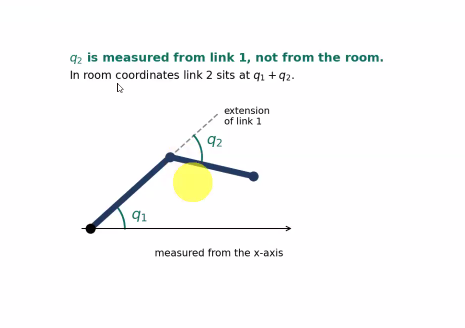
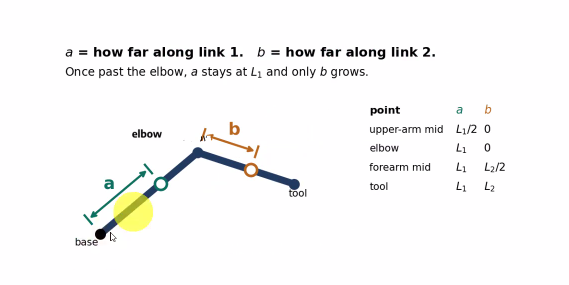
<p align="center">
<img src="/content/ssm/shared/diagrams/two_links.png" width="460"><br>
<em>q₂ is measured from link 1, not from the room.</em>
</p>
<p align="center">
<img src="/content/ssm/shared/diagrams/ab_parametrisation.png" width="620"><br>
<em>Two independent distances — one along each link.</em>
</p>

The arm has a shoulder joint at angle $q_1$ and an elbow at angle $q_2$. Follow
the first link out from the origin, then the second link from wherever that
ended.

**The catch, and it is the one people get wrong:** $q_2$ is measured *relative to
the first link*, the way your forearm angle is relative to your upper arm - not
relative to the room. So the second link's angle in room coordinates is
$q_1 + q_2$.

$$p = \underbrace{\begin{bmatrix} a\cos q_1 \\ a\sin q_1\end{bmatrix}}_{\text{along link 1}}
+ \underbrace{\begin{bmatrix} b\cos(q_1{+}q_2) \\ b\sin(q_1{+}q_2)\end{bmatrix}}_{\text{along link 2}}$$

### Why $a$ and $b$ instead of $L_1$ and $L_2$

Because we do not only care about the hand. We care about the **elbow**, and the
**middle of each link**, because any of them can be the part nearest the person.
Writing the function with distances $(a, b)$ along each link means **one function
covers every point on the arm**:

| point on the arm | $a$ | $b$ |
|---|---|---|
| middle of the upper arm | $L_1/2$ | $0$ |
| the elbow | $L_1$ | $0$ |
| middle of the forearm | $L_1$ | $L_2/2$ |
| the hand (the "tool") | $L_1$ | $L_2$ |

You will use this exact function on all three days.

### **Question 3**
`q` is an array holding the two joint angles, so `q[0]` is $q_1$ and `q[1]` is
$q_2$. **Counting starts at zero** in Python.

<details>
<summary><b>Hint &#9656;</b></summary>

The first link is already done. For the second, the length is `b` and the angle is the **sum** of the two joint angles.

`first + second` adds the two points component by component - that is NumPy adding arrays, and it is why we returned an array in Question 2.

</details>

In [22]:
def arm_point(q, a, b):
    first  = link_end(a, q[0])
    second = link_end(b, q[0]+q[1])
    return first + second

In [23]:
grader.q0_3(arm_point, L1, L2)
MONITORED = [(L1/2, 0.0), (L1, 0.0), (L1, L2/2), (L1, L2)]
q = np.array([0.047, 1.816])   # shoulder barely turned, elbow bent right up
for (a, b) in MONITORED:
    print(f"  a={a:.2f}, b={b:.2f}  ->  {np.round(arm_point(q, a, b), 3)}")

  PASS  3.1  a straight arm reaches L1 + L2
  PASS  3.2  the elbow angle is measured RELATIVE to the first link
  PASS  3.3  it works for a point part-way along the arm
  a=0.25, b=0.00  ->  [0.25  0.012]
  a=0.50, b=0.00  ->  [0.499 0.023]
  a=0.50, b=0.20  ->  [0.442 0.215]
  a=0.50, b=0.40  ->  [0.384 0.407]


<details>
<summary><b>Show the answer &#9656;</b> <i>(try it first - that is where the learning is)</i></summary>

```python
def arm_point(q, a, b):
    first  = link_end(a, q[0])
    second = link_end(b, q[0] + q[1])
    return first + second
```

That last cell shows two more things. `MONITORED` is a **list** of **tuples** - a list is an ordered collection, a tuple is a small fixed group of values. And `for (a, b) in MONITORED:` **unpacks** each tuple into two names at once, which is tidier than `pair[0]` and `pair[1]`.

</details>

---
#### Try it E — slices
*Not graded.*

`p[0:2]` is a **slice**: from 0 **up to but not including** 2. So `[0:2]` gives
two entries, not three — the convention everywhere in Python.

Slices turn up later, when a whole column has to be pulled out of a grid.

In [24]:
v = np.array([10.0, 20.0, 30.0, 40.0])
print(v[0:2])     # [10. 20.]  -- up to but NOT including index 2
print(v[1:])      # [20. 30. 40.]  -- from 1 to the end
print(len(v))     # 4

[10. 20.]
[20. 30. 40.]
4


---
#### **Try it F — where the distance comes from**
*Not graded.*

`np.linalg.norm(a - b)` is Pythagoras, and it is worth seeing why before you
use it.

Subtracting two points gives the **arrow** from one to the other — entry by
entry, as in Try it D. The norm is that arrow's **length**:

$$\lVert \mathbf{a} - \mathbf{b} \rVert = \sqrt{(a_x - b_x)^2 + (a_y - b_y)^2}$$

<p align="center">
<img src="/content/ssm/shared/diagrams/norm_pythagoras.png" width="380">
</p>

So the separation you are about to write is a square root of a sum of squares —
the same `**` and `np.sqrt()` from Try it B, wrapped up in one function.

In [25]:
a = np.array([0.0, 0.0])
b = np.array([3.0, 4.0])

print(b - a)                       # [3. 4.]  -- the arrow from a to b
print(np.linalg.norm(b - a))       # 5.0      -- its length
print(np.sqrt(3**2 + 4**2))        # 5.0      -- the same thing, by hand

[3. 4.]
5.0
5.0


---
#### **Try it G — doing something only sometimes**
*Not graded.*

`if` runs the indented lines **only when** the condition is `True` — and the
condition is exactly the kind of comparison from Try it C.

```python
if  <something that is True or False> :
    ...runs only when it is True
else:
    ...runs otherwise
```

Two things Python insists on: the **colon** at the end of the `if` line, and the
**indentation** of the lines beneath it. The indentation is not decoration — it
is how Python knows which lines belong to the `if`.

In [26]:
d = 0.18                      # how far away the person is, in metres

if d < 0.208:
    print("too close -- no speed is safe, not even zero")
else:
    print("there is a compliant speed")

# change d to 0.30 and run it again

too close -- no speed is safe, not even zero


---
## **4 - The number the whole workshop is about**

A person is standing near the bench. How far is a point on the robot from them?

$$d = \lVert p_{\text{robot}} - p_{\text{person}}\rVert
= \sqrt{(x_r - x_h)^2 + (y_r - y_h)^2}$$

Subtracting two arrays gives the arrow from one to the other; its **length** is
the distance. `np.linalg.norm` computes that length.
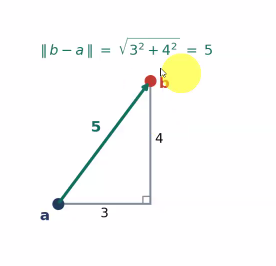
### **Question 4**
One line.

<details>
<summary><b>Hint &#9656;</b></summary>

`np.linalg.norm(something)`. The something is the **difference** of the two points.

Careful: `norm(a) - norm(b)` is a different and wrong thing - that compares how far each is from the origin, which is not what you want.

</details>

In [27]:
def separation(p_robot, p_person):
    return np.linalg.norm(p_robot - p_person)

In [28]:
grader.q0_4(separation)
person = np.array([0.55, -0.15])
print(f"  hand to person: {separation(arm_point(q, L1, L2), person):.3f} m")

  PASS  4.1  distance between two points
  PASS  4.2  a point is zero away from itself
  PASS  4.3  order does not matter
  hand to person: 0.581 m


<details>
<summary><b>Show the answer &#9656;</b> <i>(try it first - that is where the learning is)</i></summary>

```python
def separation(p_robot, p_person):
    return np.linalg.norm(p_robot - p_person)
```

`:.3f` inside the f-string means *three decimal places*. Without it you get sixteen digits of floating-point noise and cannot read the result.

</details>

---
## **5 - Which part of the robot is closest?**

Now the question that makes this a safety problem rather than an arithmetic one.
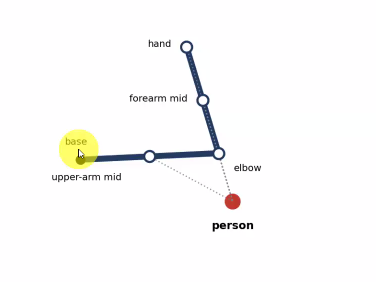
<p align="center">
<img src="/content/ssm/shared/diagrams/monitored_points.png" width="480"><br>
<em>Four monitored points, and one person. Which is closest?</em>
</p>

### **⏸ Stop and predict**

Look at the four monitored points again. The arm reaches out, the person stands
to one side. **Is the hand always the closest part of the robot to them?**

Write down yes or no before you run anything.

### **Question 5**
Compute the distance for **every** monitored point and return the smallest.

Two new pieces:
- `distances = []` makes an empty **list**; `.append(x)` adds to it.
- `min(distances)` gives the smallest value in it.

<details>
<summary><b>Hint &#9656;</b></summary>

Inside the loop you already have `p`, the position of this point, and `p_person` was passed in. You wrote the function that measures between two points in Question 4 - use it.

</details>

In [29]:
def closest(q, p_person):
    distances = []
    for (a, b) in MONITORED:
        p = arm_point(q, a, b)
        distances.append(separation(p, p_person))
    return min(distances)

In [30]:
grader.q0_5(closest, arm_point, L1, L2)
names = ["upper-arm mid", "elbow", "forearm mid", "hand"]
for name, (a, b) in zip(names, MONITORED):
    print(f"  {name:14s} {separation(arm_point(q, a, b), person):.3f} m")
print(f"  --> closest part is {closest(q, person):.3f} m away")

  PASS  5.1  you found the SMALLEST of the four distances
  PASS  5.2  and it is the closest point that matters, not the tool
  upper-arm mid  0.341 m
  elbow          0.181 m
  forearm mid    0.381 m
  hand           0.581 m
  --> closest part is 0.181 m away


<details>
<summary><b>Show the answer &#9656;</b> <i>(try it first - that is where the learning is)</i></summary>

```python
def closest(q, p_person):
    distances = []
    for (a, b) in MONITORED:
        p = arm_point(q, a, b)
        distances.append(separation(p, p_person))
    return min(distances)
```

`zip(names, MONITORED)` walks two lists side by side, so you get the label and the point together. `{name:14s}` pads the text to 14 characters so the numbers line up in a column.

</details>

**No.** In that pose the **elbow** is 0.181 m from the person while the hand is
0.581 m away - the hand is more than **three times further**. The arm is folded
so that the elbow juts toward the bench while the hand is tucked up and back.

This is not a detail. The safety standard is about the whole robot, and a
controller that watches only the tool will happily swing an elbow at somebody
while the hand retreats. On Day 2 you will impose the safety constraint at all
four of these points, using the function you just wrote.

Run the picture in the next section and you will see it immediately.

---
## 6 - A picture

Reading numbers only gets you so far. Two commands do almost everything:
`plt.plot(xs, ys)` draws a line through points, and `plt.show()` displays it.

The cell below is written for you - read it, run it, then change the joint angles
in `q` and run it again.

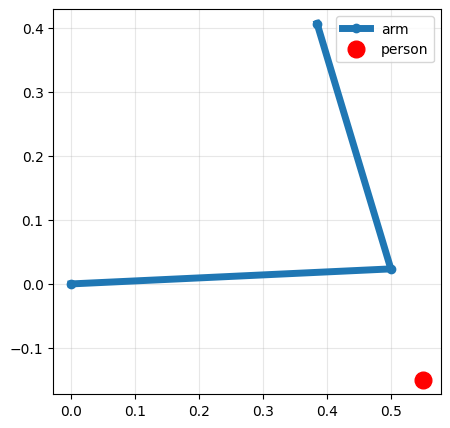

In [31]:
elbow, hand = arm_point(q, L1, 0.0), arm_point(q, L1, L2)
plt.figure(figsize=(5, 5))
plt.plot([0, elbow[0], hand[0]], [0, elbow[1], hand[1]], 'o-', lw=5, label="arm")
plt.plot(*person, 'ro', ms=12, label="person")
plt.axis('equal'); plt.grid(alpha=.3); plt.legend(); plt.show()

---
## 7 - Symbols are not numbers

Everything so far worked on **numbers**. To keep a robot safe we need something
else: to ask a computer *"what joint speeds keep the arm away from the person?"*
and have it work the answer out.

That means writing down the question without knowing the answer - with
**symbols**.

```python
x = ca.SX.sym("x")     # x is a symbol.  It has no value.
x**2 + 3               # this is an EXPRESSION, not a number
```

CasADi is the library that handles symbols. It has its own versions of the maths
functions, and **you must use the matching pair**:

| working with | use |
|---|---|
| numbers | `np.cos`, `np.sin`, `np.sqrt` |
| symbols | `ca.cos`, `ca.sin`, `ca.sqrt` |

Mixing them is the most common error in this workshop. Run the next cell to see
what it looks like when it goes wrong - **this cell is supposed to fail.**

In [32]:
x = ca.SX.sym("x")
try:
    np.cos(x)                       # numpy has no idea what a symbol is
except Exception as e:
    print("np.cos on a symbol ->", type(e).__name__, str(e)[:60])
print("ca.cos on a symbol  ->", ca.cos(x))

ca.cos on a symbol  -> cos(x)


`try:` / `except:` runs code that might fail and catches the failure instead of
stopping the notebook. Useful - but never write a bare `except:` that hides
*every* error, or you will spend an afternoon debugging something the computer
was trying to tell you.

### Question 6
Build the expression $\cos(x) + x^2$ symbolically.

<details>
<summary><b>Hint &#9656;</b></summary>

`ca.cos(x)` for the first part; `x**2` works on symbols exactly as it does on numbers. Add them with `+`.

</details>

In [33]:
x = ca.SX.sym("x")
expr = ca.cos(x) + x ** 2          # build  cos(x) + x**2  as a SYMBOL
print(expr)

(cos(x)+sq(x))


In [34]:
grader.q0_6(expr)

  PASS  6.1  you built a symbolic expression, not a number


True

<details>
<summary><b>Show the answer &#9656;</b> <i>(try it first - that is where the learning is)</i></summary>

```python
x = ca.SX.sym("x")
expr = ca.cos(x) + x**2
print(expr)
```

Notice the print did not show a number. It showed the *structure* of the calculation - that is what lets a solver reason about it.

</details>

---
## **8 - Your first optimisation**

An **optimiser** searches for the value that makes a quantity as small as
possible. Picture a marble rolling to the bottom of a bowl.

The bowl: $(x-3)^2$. Smallest at $x = 3$, obviously.

Now put a wall in: $x \ge 5$. The marble cannot get to 3 any more.

### ⏸ Stop and predict

**Where does it end up?** Write the number down.

The six lines below are the whole pattern, and you will meet them again in the
first ten minutes of Day 1:

```python
opti = ca.Opti()              # a new problem
x    = opti.variable()        # something to solve for
opti.minimize( ... )          # what to make small
opti.subject_to( ... )        # what must be true
opti.solver("ipopt", ...)     # which solver
opti.solve()                  # go
```

### Question 7
Add the constraint.

<details>
<summary><b>Hint &#9656;</b></summary>

`opti.subject_to(x >= 5)`.

Writing `x >= 5` on a line by itself does **nothing** - Python evaluates it and throws it away, and the solver never hears about it. It has to be handed to `opti.subject_to(...)`. This fails *silently*, which is what makes it nasty.

</details>

In [36]:
opti = ca.Opti()
x = opti.variable()
opti.minimize((x - 3)**2)
opti.subject_to(x>=5)                                  # add the constraint  x >= 5
opti.solver("ipopt", {"ipopt.print_level": 0, "print_time": 0})
x_star = float(opti.solve().value(x))
print(f"the solver landed on x = {x_star:.4f}")

the solver landed on x = 5.0000


In [37]:
grader.q0_7(x_star)

  PASS  7.1  the constrained answer sits ON the constraint


True

<details>
<summary><b>Show the answer &#9656;</b> <i>(try it first - that is where the learning is)</i></summary>

```python
opti = ca.Opti()
x = opti.variable()
opti.minimize((x - 3)**2)
opti.subject_to(x >= 5)
opti.solver("ipopt", {"ipopt.print_level": 0, "print_time": 0})
x_star = float(opti.solve().value(x))
print(f"the solver landed on x = {x_star:.4f}")
```

The answer is 5, not 3 - the marble rests **against** the wall. That is what a constrained optimum usually looks like: pressed right up against the thing stopping it, giving away nothing more than it has to.

</details>

> That is the idea the whole workshop is built on. A safety rule is a **wall**,
> the robot's speed is the **marble**, and the controller finds the fastest
> motion that still respects the wall.
>
> Day 1 opens by asking you to write exactly this cell - so your first minute in
> the room will be familiar ground.

---
## 9 - The gate

Run this and send me the output before Day 1. If anything says FAIL, send it
anyway - that is what it is for, and it is much better to sort it out now than
in the room.

In [38]:
grader.reset()
grader.q0_1(L1, L2); grader.q0_2(link_end); grader.q0_3(arm_point, L1, L2)
grader.q0_4(separation); grader.q0_5(closest, arm_point, L1, L2)
grader.q0_6(expr); grader.q0_7(x_star)
print("\n  " + ("READY FOR DAY 1" if grader.summary() else "NOT READY -- send me this output"))

  PASS  1.1  the two link lengths
  PASS  2.1  a link pointing straight right ends at (length, 0)
  PASS  2.2  a link pointing straight up ends at (0, length)
  PASS  3.1  a straight arm reaches L1 + L2
  PASS  3.2  the elbow angle is measured RELATIVE to the first link
  PASS  3.3  it works for a point part-way along the arm
  PASS  4.1  distance between two points
  PASS  4.2  a point is zero away from itself
  PASS  4.3  order does not matter
  PASS  5.1  you found the SMALLEST of the four distances
  PASS  5.2  and it is the closest point that matters, not the tool
  PASS  6.1  you built a symbolic expression, not a number
  PASS  7.1  the constrained answer sits ON the constraint

  13 / 13 checks passed

  READY FOR DAY 1


---
## What you just did

You wrote, from nothing:

- `link_end` - where one link ends
- `arm_point` - where **any** point on a two-link arm is
- `separation` - the distance between a robot point and a person
- `closest` - which part of the robot is nearest, which is **not always the hand**
- a symbolic expression, and a constrained optimisation

That is not a toy version of the workshop's mathematics. `arm_point` is used
unchanged on all three days, `closest` is the core of Day 2's safety constraint,
and the marble is Day 1's opening block.

### Python you now know

functions with `def` and `return` · f-strings and `:.3f` formatting · lists and
`.append` · tuples and unpacking · `for` loops · `min` · `zip` · `import` ·
`try`/`except` · NumPy arrays, `np.cos`/`np.sin`/`np.pi`, `np.linalg.norm` ·
plotting with `plt.plot` · CasADi symbols and `Opti`

**Deliberately not covered**, because nothing asks you to write them: classes,
decorators, pandas, generators, `*args`, type hints. If you have never met those
words, you have lost nothing.

### If you want more on Day 1

- The official [Python tutorial](https://docs.python.org/3/tutorial/), sections
  3–5, is the standard reference and takes about an hour.
- [Data 8: Computational and Inferential Thinking](https://inferentialthinking.com)
  - chapters 3–5 teach exactly this style of Python, with the same
  fill-in-the-blank rhythm.
- The [NumPy absolute beginner's guide](https://numpy.org/doc/stable/user/absolute_beginners.html)
  if section 3 felt fast.

**Day 1 starts with the marble, and ends with you writing the safety standard's
own formula in eight lines.**